In [7]:
# ===================== 自动安装所有依赖包 =====================
import importlib
import subprocess
import sys

# 需要安装的包列表
required_packages = [
    "numpy", "pandas", "matplotlib", "seaborn", "scipy", "warnings"
]

# 自动安装缺失的包
for package in required_packages:
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"正在安装 {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("✅ 所有依赖包已准备完成！")


✅ 所有依赖包已准备完成！


In [8]:
# ==================== 导入库 =====================
import gc
gc.collect()
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')
pd.set_option('mode.chained_assignment', None)

# 绘图样式
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Arial'

In [9]:
# 工作目录
root_dir =r'C:\Users\50847\OneDrive\桌面\work'
os.chdir(root_dir)


In [10]:
# Jupyter 绘图设置
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [11]:
# ===================== 读取数据 =====================
df_site = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\sites_meta_info.csv", index_col=0)
df_SNR = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\beta_SNR_results.csv", index_col=0)
df_delta_Y = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\delta_Y_CO2_results.csv", index_col=0)


✅ 图片已保存至：
C:\Users\50847\OneDrive\桌面\work\figure\Fig1_iWUE_comparison.png


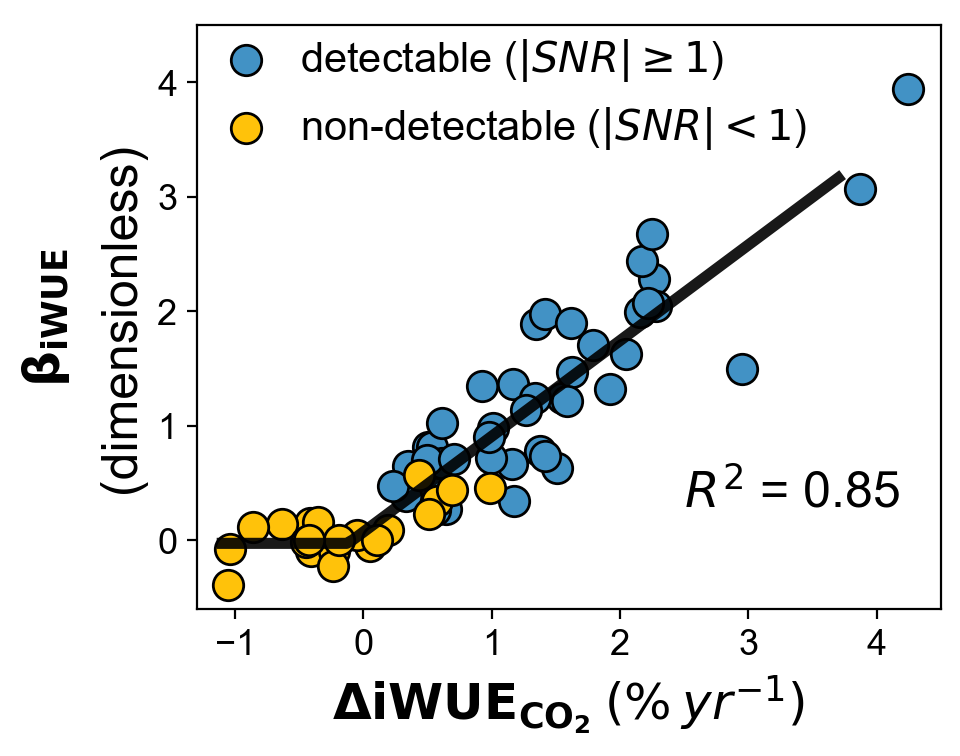

In [12]:
# ===================== 绘图数据准备 =====================
target = 'iWUE'
resi_metric = 'beta'

y_SNR = target + '_SNR'
y_beta = target + '_beta'
y_var = y_SNR if resi_metric == 'SNR' else y_beta
x_var = f'delta_{target}_CO2'

assert df_SNR.index.equals(df_delta_Y.index)
df_plot = pd.concat([df_SNR[[y_SNR, y_beta]], df_delta_Y[x_var]], axis=1)

# ===================== 绘图 =====================
fig, ax = plt.subplots(figsize=(5, 4))
blue_c, yellow_c = '#4292C5', '#FFC20A'
xmin, xmax = -1.3, 4.5

# 散点
df_plot[df_plot[y_SNR] > 1].plot(x_var, y_var, kind='scatter', ax=ax, color=blue_c, s=120, edgecolor='black', label='detectable ' + r'($|SNR| \geq 1$)')
df_plot[df_plot[y_SNR] < 1].plot(x_var, y_var, kind='scatter', ax=ax, color=yellow_c, s=120, edgecolor='black', label='non-detectable ' + r'($|SNR| < 1$)')

ax.legend(fontsize=15, bbox_to_anchor=(-0.04, 0.72), loc='lower left', handletextpad=0.3)

# 分段拟合
def piecewise_linear(x, x0, y0, k1):
    return np.piecewise(x, [x < x0], [lambda x: y0, lambda x: k1 * x + y0 - k1 * x0])

x = df_plot[x_var].values
y = df_plot[y_var].values
p, e = curve_fit(piecewise_linear, x, y)
xd = np.linspace(xmin + 0.2, xmax - 0.8, 100)
ax.plot(xd, piecewise_linear(xd, *p), linewidth=4, color='k', alpha=0.9)

# R²
y_fit = piecewise_linear(x, *p)
residuals = y - y_fit
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
ax.text(0.8, 0.2, f'$R^2$ = {r_squared:.2f}', ha='center', va='center', transform=ax.transAxes, fontsize=18)

# 坐标轴范围
if resi_metric == 'SNR':
    ax.set_ylim([-1.5, 3.5])
else:
    ax.set_ylim([-0.6, 4.5])
ax.set_xlim([xmin, xmax])

# 标签
ax.set_xlabel('$\mathbf{\Delta iWUE_{CO_2}} \: (\% \: yr^{-1})$', fontsize=18)
if resi_metric == 'SNR':
    ylabel = '$\mathbf{{SNR}_{iWUE}}$ (dimensionless)'
else:
    ylabel = r'$\mathbf{{\beta}_{iWUE}}$' + '\n(dimensionless)'
ax.set_ylabel(ylabel, fontsize=18, linespacing=1.7)

plt.tight_layout()
# 图片保存到你指定的文件夹
save_path = r'C:\Users\50847\OneDrive\桌面\work\figure\Fig1_iWUE_comparison.png'
plt.savefig(save_path, dpi=800, bbox_inches='tight')
print(f"✅ 图片已保存至：\n{save_path}")

plt.show()